<a href="https://colab.research.google.com/github/kleaa-hash/deprivation-spending-analysis/blob/main/02_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 02_analysis.ipynb
# Dissertation: A Cloud-Based Analytics Engineering Platform
# for Transparent Public-Sector Policy Analysis
# Klea Zici, 19376977, Oxford Brookes University

# This notebook contains all statistical analysis for the dissertation:
#   Descriptive statistics and outlier investigation
#   OLS regression (Model 1, Model 2, sensitivity analyses S1-S4)
#   Random Forest with Group K-Fold cross-validation
#   SHAP feature importance
#   Choropleth maps

# Authenticate with Google and connect to BigQuery

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

client = bigquery.Client(project='deprivation-spending-analysis')
print("Connected to BigQuery successfully")

Connected to BigQuery successfully


In [ ]:
# Loading the main table I built in dbt, this is the one that joins
# IMD scores, spending and population together at LA/year level.
# It should be 1,733 rows (296 authorities x 6 years, minus mergers and
# a few authorities that didn't submit data, see D7 and D11 for why
# the count isn't a clean 296 x 6).

query = """
SELECT *
FROM `deprivation-spending-analysis.spending_analysis_marts.mart_deprivation_spending`
ORDER BY lad_code, financial_year_start
"""

df = client.query(query).to_dataframe()

# Checking that everything loaded properly before I do anything
# else with it, row count, years covered and that no region or
# authority class is missing or misspelled from the join
print(f"Rows loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFinancial years: {sorted(df['financial_year_start'].unique())}")
print(f"Authorities per year:")
print(df.groupby('financial_year_start')['lad_code'].count())
print(f"\nRegions: {sorted(df['region_name'].unique())}")
print(f"\nAuthority classes: {sorted(df['la_class'].unique())}")

Rows loaded: 1733
Columns: ['year_ending', 'financial_year_start', 'lad_code', 'la_name', 'la_class', 'la_subclass', 'imd_score', 'imd_rank', 'imd_proportion_deprived_10pct', 'net_current_expenditure', 'total_service_expenditure', 'adult_social_care_expenditure', 'childrens_social_care_expenditure', 'population', 'net_current_expenditure_per_capita', 'total_service_expenditure_per_capita', 'adult_social_care_per_capita', 'childrens_social_care_per_capita', 'is_covid_year', 'region_name']

Financial years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Authorities per year:
financial_year_start
2019    289
2020    290
2021    292
2022    292
2023    283
2024    287
Name: lad_code, dtype: int64

Regions: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Authority classes: ['London', 'Met District', 'Shire District', 'Unitary Authority']


In [ ]:
# First proper look at the data before I run anything. just checking
# the numbers look sensible and spotting anything weird like outliers or
# implausible values, before it causes problems in the regression.
# Note: this is on the full dataset, City of London still included,
# so the max spending figure below will look extreme, that is expected and
# I look into it properly in the next cell.

print("\nKEY VARIABLE SUMMARY\n")

key_vars = [
    'imd_score',
    'net_current_expenditure_per_capita',
    'total_service_expenditure_per_capita',
    'adult_social_care_per_capita',
    'childrens_social_care_per_capita',
    'population'
]

print(df[key_vars].describe().round(2))

# Breaking spending down by region and authority class here because
# these are exactly the two things I end up adding as controls later
# (D18): if spending already varies a lot just by region or class on
# its own, either one could be muddying the deprivation-spending link
# if I don't control for it in the regression.

print("\nSPENDING BY REGION (average net current expenditure per capita)\n")
print(df.groupby('region_name')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\nSPENDING BY AUTHORITY CLASS\n")
print(df.groupby('la_class')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\nDEPRIVATION BY REGION (average IMD score)\n")
print(df.groupby('region_name')['imd_score'].mean().round(2).sort_values(ascending=False))


KEY VARIABLE SUMMARY

       imd_score  net_current_expenditure_per_capita  \
count    1733.00                             1733.00   
mean       20.11                             1149.94   
std         7.96                             1684.89   
min         5.91                              -80.14   
25%        13.75                              319.25   
50%        19.02                              415.26   
75%        25.61                             1852.54   
max        43.47                            29088.94   

       total_service_expenditure_per_capita  adult_social_care_per_capita  \
count                               1733.00                       1733.00   
mean                                 908.85                        162.40   
std                                 1638.78                        189.84   
min                                  -77.96                         -3.05   
25%                                  142.44                          0.00   
50%       

In [ ]:
# Following up on the two odd things that the summary stats showed,
# some negative spending values and one authority way above
# everyone else. Need to know exactly which authorities these are
# and how many rows are affected before deciding what to do about them
# (that decision happens in the next cell, D20 for the negatives,
# D21 for the high outlier).

print("NEGATIVE NET CURRENT EXPENDITURE PER CAPITA")
negative_rows = df[df['net_current_expenditure_per_capita'] < 0]
print(f"Number of rows with negative values: {len(negative_rows)}")
print(negative_rows[['lad_code', 'la_name', 'financial_year_start',
                       'net_current_expenditure_per_capita',
                       'la_class', 'region_name']].to_string())

# £5,000 isn't a proper statistical cutoff, just a number that looked
#  too high to be normal, about 4 or 5x what most authorities
# spend. I check this properly later with Cook's distance once I've
# got a regression to test it against.

print("\nEXTREMELY HIGH SPENDING (above £5,000 per capita)")
high_rows = df[df['net_current_expenditure_per_capita'] > 5000]
print(f"Number of rows above £5,000: {len(high_rows)}")
print(high_rows[['lad_code', 'la_name', 'financial_year_start',
                  'net_current_expenditure_per_capita',
                  'la_class', 'region_name']].to_string())

NEGATIVE NET CURRENT EXPENDITURE PER CAPITA
Number of rows with negative values: 4
       lad_code     la_name  financial_year_start  net_current_expenditure_per_capita        la_class region_name
1150  E07000213  Spelthorne                  2019                              -68.88  Shire District  South East
1151  E07000213  Spelthorne                  2020                              -32.56  Shire District  South East
1152  E07000213  Spelthorne                  2021                              -71.16  Shire District  South East
1153  E07000213  Spelthorne                  2022                              -80.14  Shire District  South East

EXTREMELY HIGH SPENDING (above £5,000 per capita)
Number of rows above £5,000: 6
       lad_code         la_name  financial_year_start  net_current_expenditure_per_capita la_class region_name
1535  E09000001  City of London                  2019                            24972.62   London      London
1536  E09000001  City of London            

In [ ]:
# Getting the data ready for regression
# Two decisions coming out of the descriptive stats and outlier check.
# D20: keeping Spelthorne's negative values in, they're real
# accounting data (income surplus), not an error.
# D21: dropping City of London out completely because its tiny population
# makes the per capita figure meaningless for this analysis.

# Excluding City of London (D21)
df_reg = df[df['lad_code'] != 'E09000001'].copy()

print(f"Rows after excluding City of London: {len(df_reg)}")
print(f"City of London rows removed: {len(df) - len(df_reg)}")

# Quick check to see if the spending numbers look more normal now
# that the outlier is gone. Max should be much lower than the £29k
# we saw before.
print(f"\nNet current expenditure per capita after exclusion:")
print(f"  Mean: £{df_reg['net_current_expenditure_per_capita'].mean():.2f}")
print(f"  Median: £{df_reg['net_current_expenditure_per_capita'].median():.2f}")
print(f"  Max: £{df_reg['net_current_expenditure_per_capita'].max():.2f}")
print(f"  Min: £{df_reg['net_current_expenditure_per_capita'].min():.2f}")

# statsmodels wants the COVID indicator as 0 or 1 so not True or False
df_reg['is_covid_year_int'] = df_reg['is_covid_year'].astype(int)

print(f"\nData ready for regression. {len(df_reg)} observations.")

Rows after excluding City of London: 1727
City of London rows removed: 6

Net current expenditure per capita after exclusion:
  Mean: £1065.71
  Median: £414.03
  Max: £4853.34
  Min: £-80.14

Data ready for regression. 1727 observations.


In [ ]:
# MODEL 1: the first regression
# Dependent variable: net current expenditure per capita
# Main variable of interest: imd_score
# Controls: is_covid_year, authority class dummies, region dummies
# Standard errors clustered by authority (lad_code), since each
# authority appears up to six times in the data and I don't want
# the model treating those as six independent observations
#
# Pre-stated criteria, decided before running this (D15):
# positive relationship confirmed if imd_score is positive and
# p is less than 0.05. Weak or absent if not significant or if
# R-squared is below 0.10.

# Running the OLS regression with all controls included. C() tells
# statsmodels to treat la_class and region_name as categories and
# create dummy variables automatically, rather than as numbers.
model1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(la_class) + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model1.summary())

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.918
Model:                                            OLS   Adj. R-squared:                  0.918
Method:                                 Least Squares   F-statistic:                     1226.
Date:                                Sun, 30 Aug 2026   Prob (F-statistic):          2.55e-247
Time:                                        09:49:57   Log-Likelihood:                -12007.
No. Observations:                                1727   AIC:                         2.404e+04
Df Residuals:                                    1714   BIC:                         2.411e+04
Df Model:                                          12                                         
Covariance Type:                              cluster                                         
                                                 c

In [ ]:
# Checking for multicollinearity
# Model 1's summary output threw a warning about possible
# multicollinearity, so I'm checking properly with VIF rather than
# just ignoring that warning. General rule of thumbis: VIF above 5 is
# worth a look, above 10 is a real problem.

# Building the design matrix by hand so I can check each variable
# individually. drop_first=True avoids the dummy variable trap
# (one category always has to be left out as the baseline)

X = pd.get_dummies(df_reg[['imd_score', 'is_covid_year_int', 'la_class', 'region_name']],
                   drop_first=True, dtype=float)
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF values (above 5 = moderate concern, above 10 = serious):")
print(vif_data.sort_values('VIF', ascending=False).to_string())

VIF values (above 5 = moderate concern, above 10 = serious):
                                variable       VIF
3                la_class_Shire District       inf
2                  la_class_Met District       inf
4             la_class_Unitary Authority       inf
6                     region_name_London       inf
9                 region_name_South East  2.307028
8                 region_name_North West  2.153620
5            region_name_East of England  1.963657
11             region_name_West Midlands  1.751632
12  region_name_Yorkshire and The Humber  1.740490
10                region_name_South West  1.703520
7                 region_name_North East  1.557311
0                              imd_score  1.498092
1                      is_covid_year_int  1.000174
13                             intercept  0.000000


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [ ]:
# MODEL 2: dropping la_class to fix the multicollinearity

# The VIF check above confirms D22: la_class and region_name are
# perfectly collinear for London specifically, since London Boroughs
# are both la_class = London and region_name = London at the same
# time. Dropping la_class here and keeping region_name, since region
# covers more ground across the whole country, not just London.
# Model 1 (with la_class) is kept as a sensitivity check later
# rather than thrown away, labelled Model 1a.

model2 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model2.summary())
print(f"\nimd_score coefficient: {model2.params['imd_score']:.4f}")
print(f"imd_score p-value: {model2.pvalues['imd_score']:.4f}")
print(f"R-squared: {model2.rsquared:.4f}")

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.562
Model:                                            OLS   Adj. R-squared:                  0.560
Method:                                 Least Squares   F-statistic:                     106.3
Date:                                Sun, 30 Aug 2026   Prob (F-statistic):           1.74e-91
Time:                                        09:49:57   Log-Likelihood:                -13456.
No. Observations:                                1727   AIC:                         2.693e+04
Df Residuals:                                    1716   BIC:                         2.699e+04
Df Model:                                          10                                         
Covariance Type:                              cluster                                         
                                                 c

In [ ]:
# Why is the COVID coefficient negative?

# Model 2 shows COVID years (2020-21, 2021-22) with lower spending
# per capita than other years, which is the opposite of what I'd
# expect given all the emergency COVID funding. Looking at the raw
# numbers by year to figure out what's actually going on before I
# try to explain it (see D23 once I've worked this out).

print("Average spending by year:")
yearly = df_reg.groupby('financial_year_start')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2)
yearly['is_covid'] = yearly.index.isin([2020, 2021])
print(yearly)

print("\nAverage spending COVID vs non-COVID years:")
print(df_reg.groupby('is_covid_year')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2))

Average spending by year:
                         mean  median  is_covid
financial_year_start                           
2019                   961.11  387.26     False
2020                  1029.79  447.18      True
2021                  1018.43  394.03      True
2022                  1045.84  391.35     False
2023                  1150.45  418.72     False
2024                  1192.11  427.24     False

Average spending COVID vs non-COVID years:
                  mean  median
is_covid_year                 
False          1086.76  406.95
True           1024.09  431.56


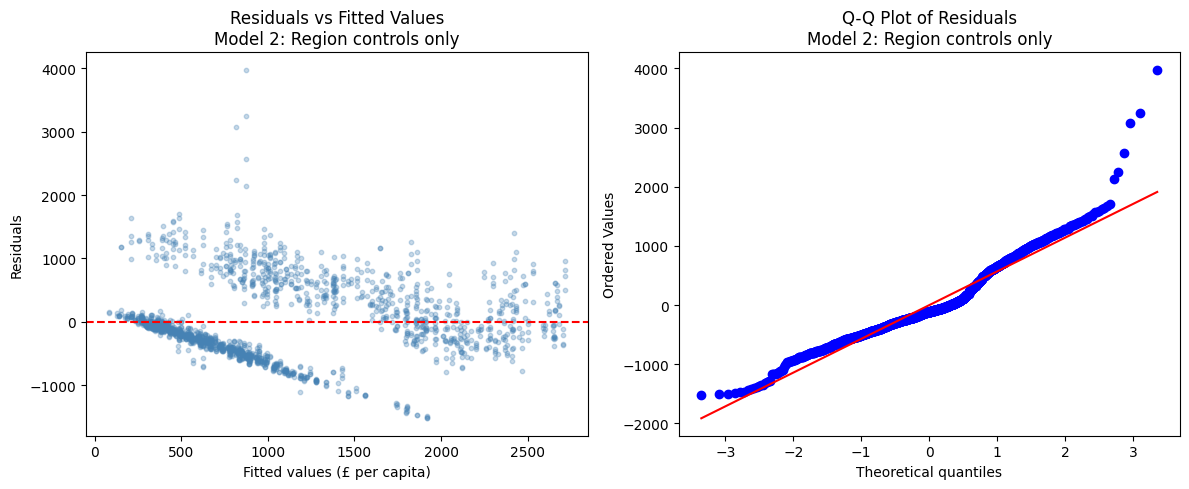

Diagnostic plots saved


In [ ]:
# Checking Model 2's assumptions with diagnostic plots

# Two things to check for a regression like this:
# 1. Residuals vs fitted, to see if the spread of errors stays
#    roughly constant across the range (homoscedasticity), or
#    fans out (heteroscedasticity, which is a problem)
# 2. Q-Q plot, to see if the residuals are roughly normally
#    distributed, which the standard OLS significance tests do assume

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
fitted = model2.fittedvalues
residuals = model2.resid

axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (£ per capita)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values\nModel 2: Region controls only')

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals\nModel 2: Region controls only')

plt.tight_layout()
plt.savefig('model2_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostic plots saved")

In [ ]:
# SENSITIVITY 1: What if I drop the COVID years entirely?

# Model 2 handles COVID years (2020-21, 2021-22) with a control
# variable rather than removing them (D6). This checks whether that
# choice actually matters through running the same regression with those
# years taken out completely and seeing if imd_score moves a lot.

df_no_covid = df_reg[df_reg['is_covid_year'] == False].copy()
print(f"Observations excluding COVID years: {len(df_no_covid)}")

model_s1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + C(region_name)',
    data=df_no_covid
).fit(cov_type='cluster', cov_kwds={'groups': df_no_covid['lad_code']})

print(f"\nSensitivity 1, COVID years excluded:")
print(f"imd_score coefficient: {model_s1.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s1.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s1.rsquared:.4f}")

Observations excluding COVID years: 1147

Sensitivity 1, COVID years excluded:
imd_score coefficient: 36.4764
imd_score p-value: 0.0000
R-squared: 0.5556


In [ ]:
# SENSITIVITY 2, 3 AND 4: Swapping out the dependent variable

# S2 uses total service expenditure (line 699) instead of net
# current expenditure (line 749, the main variable, see D9). This
# strips out housing benefit and other financing items and checks
# whether the result depends on those being included.
# S3 and S4 look specifically at adult and children's social care
# spending which are the two service areas most directly tied to actual need,
# to see if the relationship holds within those categories as well.
#
# And they are being done all three in one loop since they only differ in which
# column is the dependent variable. Everything else about the
# model specification stays the same.

sensitivities = {
    'S2: Total service expenditure per capita': 'total_service_expenditure_per_capita',
    'S3: Adult social care per capita': 'adult_social_care_per_capita',
    'S4: Children social care per capita': 'childrens_social_care_per_capita'
}

for name, dep_var in sensitivities.items():
    model_s = smf.ols(
        formula=f'{dep_var} ~ imd_score + is_covid_year_int + C(region_name)',
        data=df_reg
    ).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

    print(f"\n{name}:")
    print(f"  imd_score coefficient: {model_s.params['imd_score']:.4f}")
    print(f"  imd_score p-value: {model_s.pvalues['imd_score']:.4f}")
    print(f"  R-squared: {model_s.rsquared:.4f}")


S2: Total service expenditure per capita:
  imd_score coefficient: 28.1740
  imd_score p-value: 0.0000
  R-squared: 0.5003

S3: Adult social care per capita:
  imd_score coefficient: 5.4665
  imd_score p-value: 0.0000
  R-squared: 0.4293

S4: Children social care per capita:
  imd_score coefficient: 5.8818
  imd_score p-value: 0.0000
  R-squared: 0.4990


In [ ]:
# RANDOM FOREST MODEL

# Trying Random Forest alongside OLS since it can pick up on
# non-linear relationships that a straight line model like OLS
# can not capture. Using the same features as Model 2 so
# the two are actually comparable rather than testing different
# things. la_class is left out here too for the same reason as Model 2
# (D22) plus one more reason specific to Random Forest. Even
# though tree models do not break down under collinearity the way
# OLS does, SHAP values still end up split unpredictably between
# correlated features, which would make the feature importance
# results hard to trust (D24).

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap

# Turning region into dummy variables, same approach as Model 2
df_rf = pd.get_dummies(
    df_reg[['imd_score', 'is_covid_year_int', 'region_name',
            'net_current_expenditure_per_capita', 'lad_code', 'la_name']],
    columns=['region_name'],
    drop_first=True,
    dtype=float
)

# Splitting into features (X) and what I'm predicting (y)
feature_cols = [c for c in df_rf.columns if c not in
                ['net_current_expenditure_per_capita', 'lad_code', 'la_name']]
X = df_rf[feature_cols]
y = df_rf['net_current_expenditure_per_capita']

print(f"Features used: {feature_cols}")
print(f"Observations: {len(X)}")

# Standard 80/20 train/test split to start with. Flagging now:
# this random split doesn't account for the same authority appearing
# in both train and test across different years, which
# matters a lot. See the Group K-Fold cell further down for why.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 500 trees which is a common choice for a dataset this size. It gives stable
# results without taking too long to run. random_state fixed so the
# result is reproducible if I run this again.
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1  # use all available CPU cores
)
rf_model.fit(X_train, y_train)

# Checking how well it predicts on the held-out test set
y_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest R-squared on test set: {rf_r2:.4f}")
print(f"OLS Model 2 R-squared for comparison: 0.5624")

# Which features the model actually relied on most
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance ranking:")
print(importance_df.to_string())

Features used: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']
Observations: 1727

Random Forest R-squared on test set: 0.9354
OLS Model 2 R-squared for comparison: 0.5624

Feature importance ranking:
                                feature  importance
0                             imd_score    0.579681
3                    region_name_London    0.265956
4                region_name_North East    0.028447
9  region_name_Yorkshire and The Humber    0.026418
2           region_name_East of England    0.024611
6                region_name_South East    0.023195
5                region_name_North West    0.019254
7                region_name_South West    0.018686
8             region_name_West Midlands    0.008422
1                     is_covid_year_int    0.005331


SHAP values calculated for 1727 observations
Features: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']


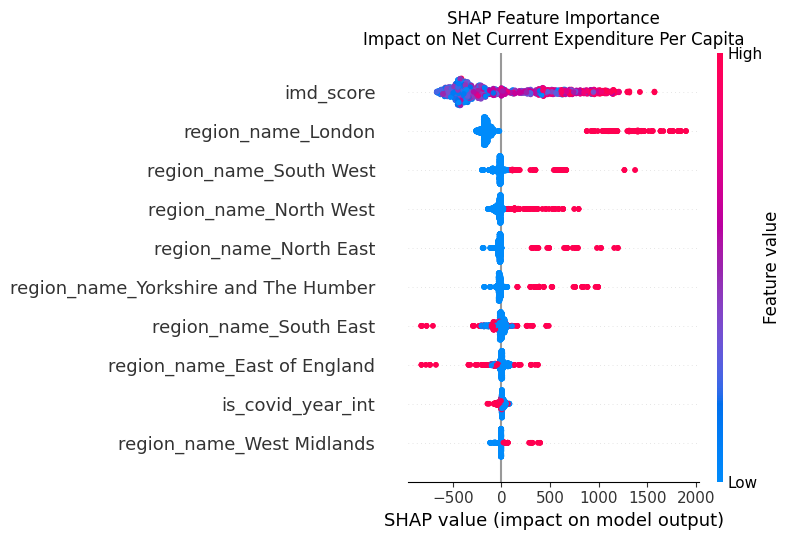

SHAP summary plot saved


In [ ]:
# SHAP VALUES: explaining individual predictions

# Random Forest can tell me an authority's predicted spending, but
# it can not show why it landed there. SHAP fills that gap. It breaks down
# each prediction into how much each feature pushed it up or down
# for that specific authority. This is one way of partially
# meeting Busuioc's Explanation dimension, though only really for
# someone who already understands what SHAP values are (D24).
#
# Important note on what X is here: this is the full 1,727-row
# dataset, not just the 346-row test set used to check R-squared
# above. That is okay for looking at feature contributions, but it
# does mean these SHAP values include rows the model was trained
# on andnot just held-out predictions.

# TreeExplainer works well with tree-based models like Random
# Forest and gives exact SHAP values rather than an approximation
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

print(f"SHAP values calculated for {len(shap_values)} observations")
print(f"Features: {feature_cols}")

# This plot shows which features matter most overall and whether
# high or low values of each feature push predictions up or down
shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance\nImpact on Net Current Expenditure Per Capita')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

In [ ]:
# CHECKING FOR OVERFITTING WITH CROSS-VALIDATION

# A single train/test split giving an R-squared of 0.935 seems almost too good
# and it might be because the split happened to be favourable.
# To check whether the model is actually performing consistently I used 5-fold cross-
# validation. This tests the model on five different splits of the data and
# averages the results which gives a more reliable idea of how well it performs.

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"5-fold CV R-squared scores: {cv_scores.round(4)}")
print(f"Mean CV R-squared: {cv_scores.mean():.4f}")
print(f"Std CV R-squared: {cv_scores.std():.4f}")
print(f"\nFor comparison:")
print(f"Single test set R-squared: 0.9354")
print(f"OLS Model 2 R-squared: 0.5624")

5-fold CV R-squared scores: [  -9.1934  -16.9257 -183.0525   -1.1636   -7.4014]
Mean CV R-squared: -43.5473
Std CV R-squared: 69.9335

For comparison:
Single test set R-squared: 0.9354
OLS Model 2 R-squared: 0.5624


In [ ]:
# FIXING THE CROSS-VALIDATION WITH GROUP K-FOLD

# The issue with the standard 5-fold CV above is that it splits by row
# rather than by authority. This means different years from the same
# council can end up in both the training and test sets. The model
# could then learn patterns specific to a council instead of learning
# a relationship that works more generally.
# Group K-Fold avoids this by keeping all years for each authority
# together. An authority is either entirely in the training set or
# entirely in the test set, so the model is tested on authorities it
# has not seen before. This gives a more realistic idea of how well
# the model actually generalises.


from sklearn.model_selection import GroupKFold, cross_val_score

# lad_code is what defines the groups so that all six years for
# one authority stay together
groups = df_rf['lad_code']

gkf = GroupKFold(n_splits=5)

cv_scores_group = cross_val_score(
    rf_model, X, y,
    cv=gkf,
    groups=groups,
    scoring='r2',
    n_jobs=-1
)

print(f"Group K-Fold CV R-squared scores: {cv_scores_group.round(4)}")
print(f"Mean Group CV R-squared: {cv_scores_group.mean():.4f}")
print(f"Std Group CV R-squared: {cv_scores_group.std():.4f}")
print(f"\nFor comparison:")
print(f"Standard CV R-squared (misleading): -43.55")
print(f"Single test set R-squared (misleading): 0.9354")
print(f"OLS Model 2 R-squared: 0.5624")

Group K-Fold CV R-squared scores: [0.3363 0.3386 0.2813 0.3247 0.0974]
Mean Group CV R-squared: 0.2757
Std Group CV R-squared: 0.0915

For comparison:
Standard CV R-squared (misleading): -43.55
Single test set R-squared (misleading): 0.9354
OLS Model 2 R-squared: 0.5624


In [ ]:
# Loading the ONS boundary file so the maps can be drawn

import geopandas as gpd

boundaries = gpd.read_file('/content/Local_Authority_Districts_December_2024_Boundaries_UK_BGC_7423724764112241180.geojson')

# Checking it loaded properly before doing anything else

print(f"Boundaries loaded: {len(boundaries)} features")
print(f"Columns: {list(boundaries.columns)}")
print(f"\nGeometry type check:")
print(boundaries.geometry.head())

Boundaries loaded: 361 features
Columns: ['FID', 'LAD24CD', 'LAD24NM', 'LAD24NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']

Geometry type check:
0    MULTIPOLYGON (((-1.23001 54.62512, -1.2299 54....
1    MULTIPOLYGON (((-1.27712 54.54791, -1.2772 54....
2    MULTIPOLYGON (((-1.20098 54.57763, -1.20037 54...
3    MULTIPOLYGON (((-1.27493 54.55187, -1.27546 54...
4    POLYGON ((-1.638 54.6172, -1.63767 54.6167, -1...
Name: geometry, dtype: geometry


In [ ]:
# CHECKING THE CUMBRIA/NORTH YORKSHIRE COVERAGE GAP

# Checking this before building the map data, BECAUSE it affects how
# the 2022-23 snapshot should be described. Cumberland, Westmorland
# and Furness as well as North Yorkshire were all created via 2023
# mergers. Checking whether they show up for 2022 under either
# their new codes or their old predecessor codes.

year_2022_all = df[df['financial_year_start'] == 2022]
print(f"Total rows in raw df for 2022: {len(year_2022_all)}")

merger_authorities = ['E06000063', 'E06000064', 'E06000065']
print(df[(df['financial_year_start'] == 2022) & (df['lad_code'].isin(merger_authorities))][['lad_code', 'la_name']])

predecessor_codes = ['E07000026', 'E07000027', 'E07000028', 'E07000029',
                      'E07000030', 'E07000031',
                      'E07000163', 'E07000164', 'E07000165']
print(df[(df['financial_year_start'] == 2022) & (df['lad_code'].isin(predecessor_codes))][['lad_code', 'la_name']])

# Both come back empty. These areas are genuinely absent from
# 2022-23 under any code and not just missing from a later map join.
# This is the D7 join issue: Revenue Outturn still uses predecessor
# codes pre-merger, IMD 2025 only has the post-merger codes so
# they can never match for this period. Kept in mind for D25 below.

In [ ]:
# CHECKING THE BOUNDARY FILE ACTUALLY MATCHES THE MART DATA

# The boundary file covers the whole UK, so filtering down to just
# England first using the code prefixes (E06/E07/E08/E09 are all
# English local authority types).Then comparison of the codes against
# what is actually in the mart table. In this way it can be known
# for certain the maps will join up properly rather than silently dropping authorities.

code_col = 'LAD24CD'  # confirmed from the columns list earlier

boundaries_eng = boundaries[
    boundaries[code_col].str.startswith(('E06', 'E07', 'E08', 'E09'))
].copy()
boundaries_eng = boundaries_eng.rename(columns={code_col: 'lad_code'})

print(f"English authorities in boundary file: {len(boundaries_eng)}")

# Comparing the two sets of codes directly rather than assuming they
# match. Anything in one set but not the other means the map will
# be missing an authority when they are merged

mart_codes = set(df_reg['lad_code'].unique())
boundary_codes = set(boundaries_eng['lad_code'])

missing_from_boundaries = mart_codes - boundary_codes
missing_from_mart = boundary_codes - mart_codes

print(f"\nMart codes not in boundary file: {len(missing_from_boundaries)}")
if missing_from_boundaries:
    print(missing_from_boundaries)

print(f"\nBoundary codes not in mart data: {len(missing_from_mart)}")
if missing_from_mart:
    print(missing_from_mart)

English authorities in boundary file: 296

Mart codes not in boundary file: 0

Boundary codes not in mart data: 1
{'E09000001'}


In [ ]:
# GETTING THE DATA READY FOR THE MAPS

# Using 2022-23 as the snapshot year. It avoids the non-submission
# gap in 2023-24/2024-25 (Birmingham and others, D11) and has
# fewer missing authorities overall than 2023-24 (292 vs 283,
# checked directly). Already know from the check above that this
# year has its own gap though, Cumberland, Westmorland and
# Furness as well as North Yorkshire are structurally absent. See D25.

df_reg['model2_residual'] = model2.resid

df_map = df_reg[df_reg['financial_year_start'] == 2022][
    ['lad_code', 'la_name', 'imd_score', 'net_current_expenditure_per_capita',
     'region_name', 'model2_residual']
].copy()

print(f"Authorities in 2022-23 snapshot: {len(df_map)}")

gdf_map = boundaries_eng.merge(df_map, on='lad_code', how='inner')
print(f"Matched to boundaries: {len(gdf_map)} authorities")

Authorities in 2022-23 snapshot: 291
Matched to boundaries: 291 authorities


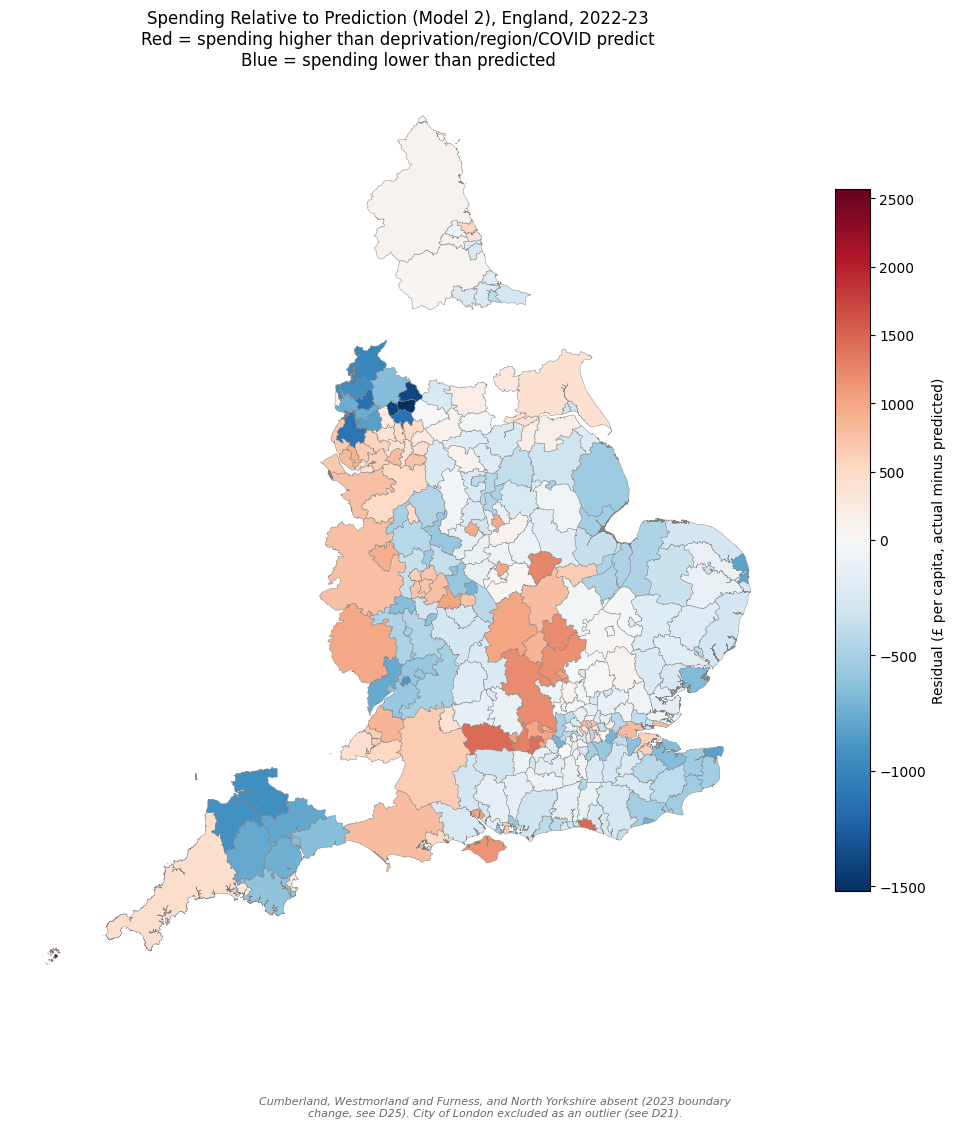

Residuals map saved


In [ ]:
# THE RESIDUALS MAP

# What this map is showing is whether an authority spent more
# or less than Model 2 predicted, after deprivation, region and
# COVID year are already factored in. Red means higher than
# predicted. Blue means lower. Zero sits right in the middle of the
# colour scale (D27), so nothing on either side gets visually
# exaggerated compared to the other.

from matplotlib.colors import TwoSlopeNorm

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
norm = TwoSlopeNorm(
    vmin=gdf_map['model2_residual'].min(),
    vcenter=0,
    vmax=gdf_map['model2_residual'].max()
)
gdf_map.plot(
    column='model2_residual',
    cmap='RdBu_r',
    norm=norm,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Residual (£ per capita, actual minus predicted)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Spending Relative to Prediction (Model 2), England, 2022-23\n'
              'Red = spending higher than deprivation/region/COVID predict\n'
              'Blue = spending lower than predicted', fontsize=12)
ax.axis('off')

# Caption noting the two known gaps on the map (D21, D25)
fig.text(0.5, 0.02,
         "Cumberland, Westmorland and Furness, and North Yorkshire absent (2023 boundary\n"
         "change, see D25). City of London excluded as an outlier (see D21).",
         ha='center', fontsize=8, style='italic', color='dimgrey')

plt.tight_layout()
plt.savefig('map_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residuals map saved")

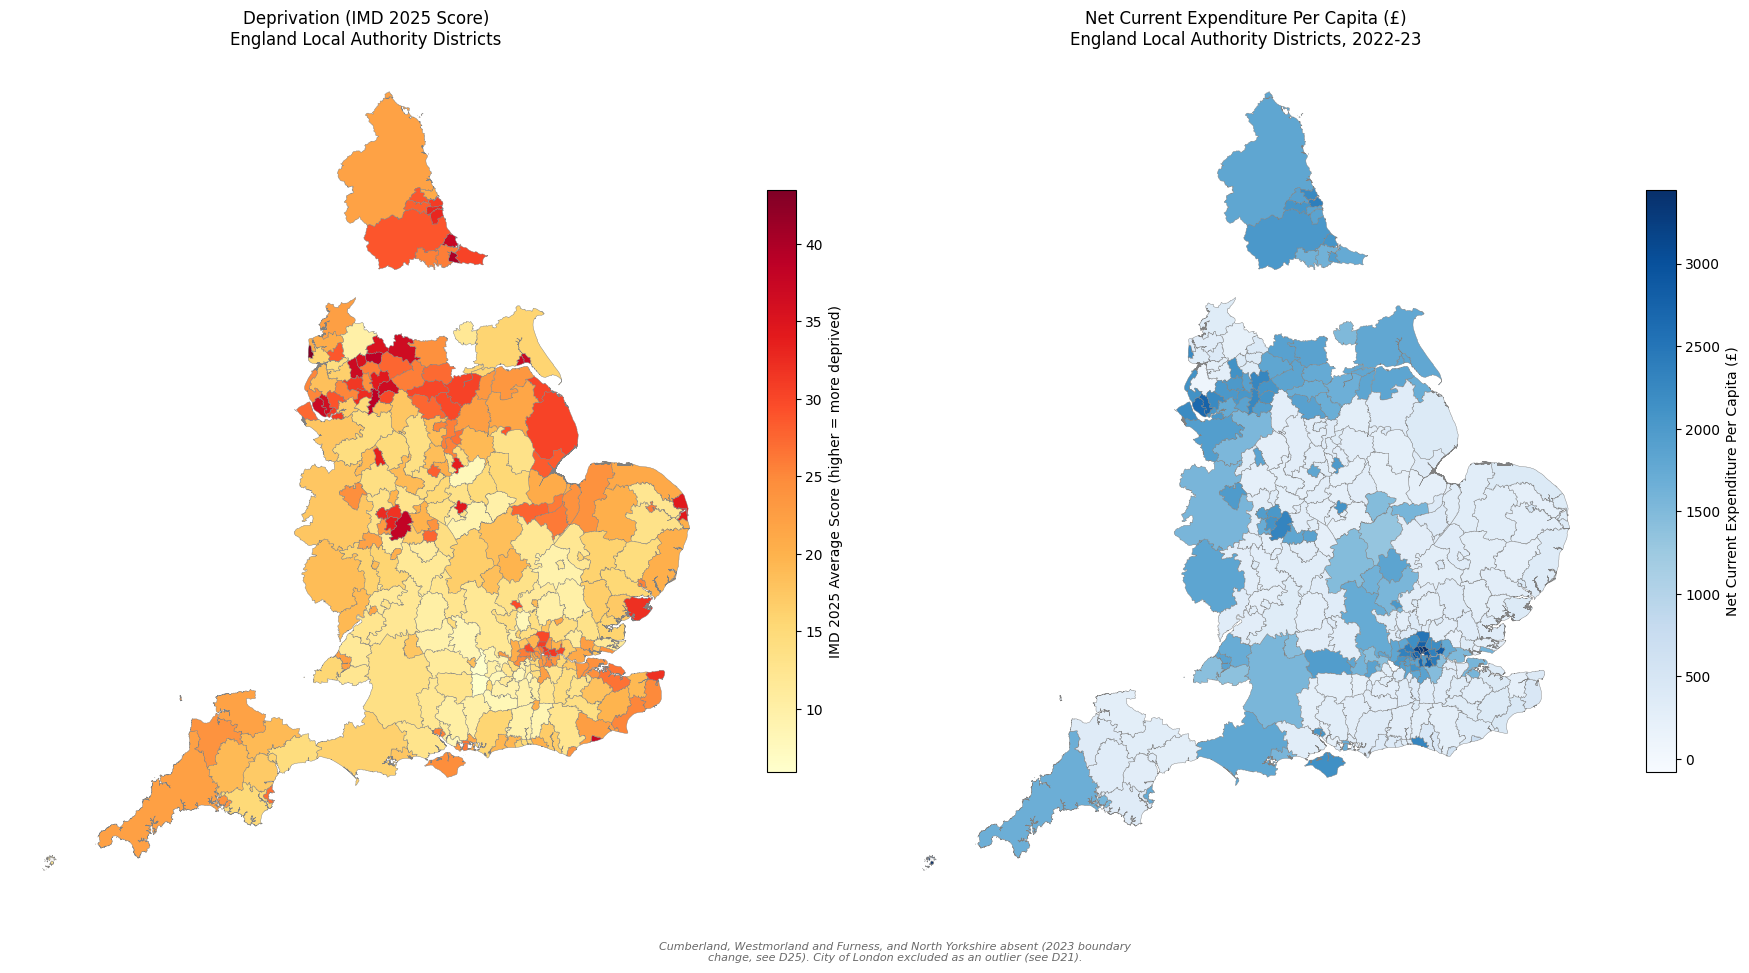

IMD and spending maps saved


In [ ]:
# IMD SCORE AND SPENDING PER CAPITA MAPS

# The residuals map on its own only shows whether spending came in
# above or below what was expected. It does not show what
# deprivation or spending actually looked like across the country,
# which is what these two maps add. Using the same 2022-23 snapshot
# throughout means all three maps stay consistent with each other.

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Where deprivation is concentrated
gdf_map.plot(
    column='imd_score',
    cmap='YlOrRd',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'IMD 2025 Average Score (higher = more deprived)', 'shrink': 0.6},
    ax=axes[0]
)
axes[0].set_title('Deprivation (IMD 2025 Score)\nEngland Local Authority Districts', fontsize=12)
axes[0].axis('off')

# Where spending is concentrated
gdf_map.plot(
    column='net_current_expenditure_per_capita',
    cmap='Blues',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Net Current Expenditure Per Capita (£)', 'shrink': 0.6},
    ax=axes[1]
)
axes[1].set_title('Net Current Expenditure Per Capita (£)\nEngland Local Authority Districts, 2022-23', fontsize=12)
axes[1].axis('off')

# Same coverage caption as the residuals map, since this uses the
# same 2022-23 snapshot and also has the same gaps (D21, D25)
fig.text(0.5, 0.02,
         "Cumberland, Westmorland and Furness, and North Yorkshire absent (2023 boundary\n"
         "change, see D25). City of London excluded as an outlier (see D21).",
         ha='center', fontsize=8, style='italic', color='dimgrey')

plt.tight_layout()
plt.savefig('map_imd_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("IMD and spending maps saved")

In [ ]:
# WHICH AUTHORITIES STAND OUT MOST IN THE RESIDUALS

# Pulling out the ten authorities spending furthest above prediction
# and the ten furthest below so that I can name specific examples rather
# than just describing the map in general terms.


print("TOP 10 MOST POSITIVE RESIDUALS (spending higher than predicted)")
print(df_map.nlargest(10, 'model2_residual')[
    ['la_name', 'region_name', 'imd_score', 'model2_residual']
].to_string())

print("\nTOP 10 MOST NEGATIVE RESIDUALS (spending lower than predicted)")
print(df_map.nsmallest(10, 'model2_residual')[
    ['la_name', 'region_name', 'imd_score', 'model2_residual']
].to_string())

TOP 10 MOST POSITIVE RESIDUALS (spending higher than predicted)
                     la_name      region_name  imd_score  model2_residual
296          Isles of Scilly       South West     12.650      2568.033175
242       Brighton & Hove UA       South East     20.266      1482.240099
207        West Berkshire UA       South East     11.049      1458.142508
201      Bracknell Forest UA       South East     10.084      1411.046122
230             Wokingham UA       South East      6.102      1291.792918
99                Rutland UA    East Midlands      9.851      1259.259759
308               Bedford UA  East of England     19.747      1216.986501
337       Buckinghamshire UA       South East     11.921      1216.829533
314  Central Bedfordshire UA  East of England     13.102      1163.900502
260         Isle of Wight UA       South East     24.599      1162.815087

TOP 10 MOST NEGATIVE RESIDUALS (spending lower than predicted)
             la_name region_name  imd_score  model2_residu

In [ ]:
# IS THE NW CLUSTER ABOUT GEOGRAPHY OR ABOUT AUTHORITY TYPE?

# la_class isn't in Model 2 at all, it got dropped back in D22
# because of the London collinearity issue. Shire Districts spend
# a lot less than other authority types for reasons that
# have nothing to do with deprivation, they simply don't run
# social care. Worth checking whether these seven authorities are
# all Shire Districts and whether the residual holds up once that
# is accounted for.

nw_check = df_reg[df_reg['la_name'].isin(
    ['Burnley', 'Hyndburn BC', 'Pendle', 'Preston', 'Rossendale',
     'West Lancashire', 'Lancaster']
)][['la_name', 'la_class']].drop_duplicates()
print(nw_check)

             la_name        la_class
787          Burnley  Shire District
805      Hyndburn BC  Shire District
811        Lancaster  Shire District
817           Pendle  Shire District
822          Preston  Shire District
834       Rossendale  Shire District
846  West Lancashire  Shire District


In [ ]:
# All seven confirmed as Shire District. Running an informal version
# of the regression with la_class added back in just to see what
# happens to the residuals, not as a replacement for the primary
# model.

model_check = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name) + C(la_class)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

df_reg['model_check_residual'] = model_check.resid
print(df_reg[df_reg['la_name'].isin(
    ['Burnley', 'Hyndburn BC', 'Pendle', 'Preston', 'Rossendale',
     'West Lancashire', 'Lancaster']
)].groupby('la_name')['model_check_residual'].mean().round(2).sort_values())

# Residuals shrink by roughly 80-93% once authority type is
# included. Most of the apparent North West pattern turns out to
# be a Shire District effect, not a geography or deprivation
# effect. See D26.

la_name
Burnley           -243.07
Pendle            -194.27
Hyndburn BC       -169.53
Rossendale        -136.37
Preston            -97.39
West Lancashire    -94.85
Lancaster          -69.69
Name: model_check_residual, dtype: float64


In [ ]:
# Looking at Isles of Scilly's actual figures rather than just the
# residual since it's such a small authority that the raw numbers
# are worth checking before drawing any conclusions from them.

print(df_reg[df_reg['la_name'].str.contains('Scilly', case=False, na=False)][
    ['lad_code', 'la_name', 'financial_year_start', 'population',
     'net_current_expenditure', 'net_current_expenditure_per_capita', 'imd_score']
].to_string())

      lad_code          la_name  financial_year_start  population  net_current_expenditure  net_current_expenditure_per_capita  imd_score
293  E06000053  Isles of Scilly                  2019        2098                   6314.0                             3009.53      12.65
294  E06000053  Isles of Scilly                  2020        2030                   7914.0                             3898.52      12.65
295  E06000053  Isles of Scilly                  2021        2271                   6950.0                             3060.33      12.65
296  E06000053  Isles of Scilly                  2022        2340                   8054.0                             3441.88      12.65
297  E06000053  Isles of Scilly                  2023        2433                  10018.0                             4117.55      12.65
298  E06000053  Isles of Scilly                  2024        2366                  11483.0                             4853.34      12.65


In [ ]:
# Quick check on the overall numbers before moving on, total
# authority count and total rows to make sure nothing looks
# obviously wrong at this point.
print(f"Total unique authorities in mart: {df_reg['lad_code'].nunique()}")
print(f"Total rows: {len(df_reg)}")

# Also checking Birmingham specifically, since it's a familiar and
# large authority. It should show up for the earlier years and be
# missing for 2023-24 and 2024-25, per D11.
print(df_reg[df_reg['la_name'].str.contains('Birmingham', case=False, na=False)][
    ['financial_year_start', 'population', 'net_current_expenditure_per_capita']
])

In [ ]:
# SENSITIVITY: Excluding Isles of Scilly too (D29)

# Isles of Scilly showed up with a large positive residual and
# came up in the Cook's distance check as somewhat high-influence,
# well below City of London but still worth testing properly.
# Checking whether removing it changes the deprivation coefficient
# in any meaningful way.

df_reg_scilly = df_reg[df_reg['lad_code'] != 'E06000053'].copy()
print(f"Observations after also excluding Isles of Scilly: {len(df_reg_scilly)}")

model_s5 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_reg_scilly
).fit(cov_type='cluster', cov_kwds={'groups': df_reg_scilly['lad_code']})

print(f"\nSensitivity: Isles of Scilly excluded:")
print(f"imd_score coefficient: {model_s5.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s5.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s5.rsquared:.4f}")
print(f"\nFor comparison, Model 2 (Scilly included): coefficient 35.9208, R-squared 0.5624")

Observations after also excluding Isles of Scilly: 1721

Sensitivity — Isles of Scilly excluded:
imd_score coefficient: 36.9730
imd_score p-value: 0.0000
R-squared: 0.5887

For comparison, Model 2 (Scilly included): coefficient 35.9208, R-squared 0.5624


In [ ]:
# Checking Wokingham's population too, since it has the lowest IMD
# score among the positive residuals (6.102) and I want to rule out
# the same small-population issue that turned out to explain Isles
# of Scilly and City of London.

print(df_reg[df_reg['la_name'].str.contains('Wokingham', case=False, na=False)][
    ['lad_code', 'la_name', 'financial_year_start', 'population',
     'net_current_expenditure', 'net_current_expenditure_per_capita', 'imd_score']
].to_string())

# Population confirmed normal for a unitary authority (171,789 to
# 187,200), not a small-population artefact. This is a genuine
# finding, unlike Scilly and City of London.

      lad_code       la_name  financial_year_start  population  net_current_expenditure  net_current_expenditure_per_capita  imd_score
227  E06000041  Wokingham UA                  2019      171789                 228424.0                             1329.68      6.102
228  E06000041  Wokingham UA                  2020      174708                 270494.0                             1548.26      6.102
229  E06000041  Wokingham UA                  2021      178231                 273225.0                             1532.98      6.102
230  E06000041  Wokingham UA                  2022      181318                 290577.0                             1602.58      6.102
231  E06000041  Wokingham UA                  2023      184561                 308806.0                             1673.19      6.102
232  E06000041  Wokingham UA                  2024      187200                 316513.0                             1690.77      6.102


In [ ]:
# ONE MORE MAP: AVERAGE RESIDUALS ACROSS ALL YEARS

# Single-year residuals can pick up that year's own noise, which is
# what got checked for the North West cluster earlier. Averaging
# across all six years gives a more solid version of the map, using
# the boundary file and residuals already set up in earlier cells.

# Average residual per authority across all years
mean_resid = df_reg.groupby('lad_code')['model2_residual'].mean().reset_index()
mean_resid.columns = ['lad_code', 'mean_residual']

# Merging onto the boundary file already loaded and filtered earlier
gdf_resid = boundaries_eng.merge(mean_resid, on='lad_code', how='inner')
print(f"Average residuals map: {len(gdf_resid)} authorities")

Average residuals map: 295 authorities


In [ ]:
# THE AVERAGE RESIDUALS MAP

# A more robust version of the single-year residuals map built
# earlier. Averaging each authority's residual across all six
# years rather than looking at 2022-23 on its own.

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
norm_resid = TwoSlopeNorm(
    vmin=gdf_resid['mean_residual'].min(),
    vcenter=0,
    vmax=gdf_resid['mean_residual'].max()
)
gdf_resid.plot(
    column='mean_residual',
    cmap='RdBu_r',
    norm=norm_resid,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Mean residual (£ per capita, actual minus predicted)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Spending Relative to Prediction (Model 2), England\n'
              'Average across 2019-20 to 2024-25\n'
              'Red= spending higher than predicted, Blue = spending lower than predicted', fontsize=12)
ax.axis('off')

# Cumberland and Westmorland and Furness are each based on just 1
# year of data, North Yorkshire on 2 years and  both created in 2023.
# Everywhere else on this map is averaged over up to 6 years, so
# these three are noticeably less reliable even though they still
# show a colour rather than being blank (see D25).

fig.text(0.5, 0.02,
         "Cumberland and Westmorland and Furness based on 1 year of data each,\n"
         "North Yorkshire on 2 years, less reliable than the 6-year average shown\n"
         "elsewhere. City of London excluded as an outlier (see D21).",
         ha='center', fontsize=8, style='italic', color='dimgrey')

plt.tight_layout()
plt.savefig('map_residuals_average.png', dpi=150, bbox_inches='tight')
plt.show()
print("Average residuals map saved")

In [ ]:
# D20 completion: excluding Spelthorne to check whether its negative
# spending values are affecting the main result in any significant way.

df_no_spelthorne = df_reg[df_reg['lad_code'] != 'E07000213'].copy()
model_s7_spelthorne = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_no_spelthorne
).fit(cov_type='cluster', cov_kwds={'groups': df_no_spelthorne['lad_code']})
print(f"Sensitivity (Spelthorne excluded): imd_score = {model_s7_spelthorne.params['imd_score']:.4f}, "
      f"p = {model_s7_spelthorne.pvalues['imd_score']:.4f}, R² = {model_s7_spelthorne.rsquared:.4f}")

print(f"\nFor comparison, Model 2 (both included): coefficient 35.9208, R-squared 0.5624")

Sensitivity (Spelthorne excluded): imd_score = 35.8836, p = 0.0000, R² = 0.5619

For comparison, Model 2 (both included): coefficient 35.9208, R-squared 0.5624


In [ ]:
# INFLUENCE DIAGNOSTICS: Model 6 with City of London included

# The sensitivity check showed that including City of London wipes
# out both the coefficient size and its significance. Before taking
# that as settled, I wanted actual evidence that City of London's
# rows have genuinely extreme influence, rather than just assuming
# it from the coefficient shift alone. Cook's distance gives that.
# A row above 4/n is generally flagged as high-influence.

from statsmodels.stats.outliers_influence import OLSInfluence

# Re-run Model 6 with City of London included (non-clustered fit needed
# for OLSInfluence, cluster-robust fits don't expose leverage stats
# the same way)

df_col = df.copy()  # full dataset, City of London included
df_col['is_covid_year_int'] = df_col['is_covid_year'].astype(int)

model6_plain = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_col
).fit()  # ordinary (non-clustered) SEs, needed for influence diagnostics

influence = OLSInfluence(model6_plain)
cooks_d = influence.cooks_distance[0]

df_col['cooks_distance'] = cooks_d
threshold = 4 / len(df_col)

print(f"Cook's distance threshold (4/n): {threshold:.5f}")
print(f"\nCity of London rows — Cook's distance:")
print(df_col[df_col['lad_code'] == 'E09000001'][
    ['la_name', 'financial_year_start', 'net_current_expenditure_per_capita', 'cooks_distance']
].to_string())

print(f"\nTop 10 highest Cook's distance overall (for context):")
print(df_col.nlargest(10, 'cooks_distance')[
    ['la_name', 'financial_year_start', 'net_current_expenditure_per_capita', 'cooks_distance']
].to_string())

n_above_threshold = (df_col['cooks_distance'] > threshold).sum()
print(f"\nTotal rows above 4/n threshold: {n_above_threshold} out of {len(df_col)}")

Cook's distance threshold (4/n): 0.00231

City of London rows — Cook's distance:
             la_name  financial_year_start  net_current_expenditure_per_capita  cooks_distance
1535  City of London                  2019                            24972.62        0.143272
1536  City of London                  2020                            29088.94        0.227801
1537  City of London                  2021                            27023.36        0.193360
1538  City of London                  2022                            23371.07        0.123252
1539  City of London                  2023                            24237.40        0.133895
1540  City of London                  2024                            23671.76        0.126896

Top 10 highest Cook's distance overall (for context):
              la_name  financial_year_start  net_current_expenditure_per_capita  cooks_distance
1536   City of London                  2020                            29088.94        0.227801
1537   

In [ ]:
# Re-fitting Model 6 (City of London included) with clustered SEs
# this time, matching the exact specification used for Model 2 so
# the three-way comparison (clustered vs HC1 vs Model 2) is a fair
# one rather than comparing results from differently specified models

model6_clustered = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_col
).fit(cov_type='cluster', cov_kwds={'groups': df_col['lad_code']})

print(f"Model 6 (City of London included, clustered SEs):")
print(f"imd_score coefficient: {model6_clustered.params['imd_score']:.4f}")
print(f"imd_score p-value: {model6_clustered.pvalues['imd_score']:.4f}")
print(f"R-squared: {model6_clustered.rsquared:.4f}")

Model 6 (City of London included, clustered SEs):
imd_score coefficient: 15.5894
imd_score p-value: 0.4471
R-squared: 0.2291
